#  Problema: Clasificación del método de detección (detection_method)
### Dataset: Kaggle NASA Exoplanets (CSV en src/data_sample/)

### Objetivo y planteamiento

**Problema:** queremos predecir el `detection_method` (método de detección) a partir de características del exoplaneta y su sistema.

**Por qué es útil:** ayuda a entender qué variables están asociadas a cada método y qué sesgos hay en el catálogo (por ejemplo, algunos métodos detectan mejor planetas con periodos cortos).

**Tipo de problema:** clasificación supervisada multiclase.

**Métrica principal:** usaremos **F1-macro** porque hay desbalanceo entre clases (no queremos que el modelo solo acierte la clase mayoritaria).

## Paso 0: Importación de librerías

### Importamos librerías

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from functions import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
print("Entorno listo")

Entorno listo


## Paso 1: Carga y limpieza del dataset

### Cargamos el Dataset

In [2]:
df = load_dataset()
print("Shape:", df.shape)
df.head()

✅ Dataset cargado: cleaned_5250.csv
Shape: (5250, 13)


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


### Auditoría y limpieza de los datos

In [3]:
df_clean = audit_clean(df, drop_missing=0.6, cat_unique_max=7)
df.head()

=== AUDITORÍA ===
Shape inicial: (5250, 13)
Duplicados: 0
Shape tras quitar duplicados: (5250, 13)

=== TIPOS DE COLUMNAS (simple) ===
name -> categórica
distance -> numérica
stellar_magnitude -> numérica
planet_type -> categórica
discovery_year -> numérica
mass_multiplier -> numérica
mass_wrt -> categórica
radius_multiplier -> numérica
radius_wrt -> categórica
orbital_radius -> numérica
orbital_period -> numérica
eccentricity -> numérica
detection_method -> categórica

Numéricas: ['distance', 'stellar_magnitude', 'discovery_year', 'mass_multiplier', 'radius_multiplier', 'orbital_radius', 'orbital_period', 'eccentricity']

Categóricas: ['name', 'planet_type', 'mass_wrt', 'radius_wrt', 'detection_method']

Top 10 columnas con más missing (%):
orbital_radius       5.50
stellar_magnitude    3.07
mass_multiplier      0.44
mass_wrt             0.44
distance             0.32
radius_wrt           0.32
radius_multiplier    0.32
name                 0.00
planet_type          0.00
discovery_year

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


### Guardamos el dataset limpio

In [4]:
save_clean_dataset(df_clean, filename="exoplanets_clean.csv")

✅ Dataset guardado en: src\data_processed\exoplanets_clean.csv


## Paso 2: Predicción del detection_method en exoplanetas

### Definición del target

¿Por qué `detection_method`?

Elegimos `detection_method` porque representa la técnica con la que se detectó el planeta (tránsito, velocidad radial, etc.).  
Esto nos permite ver si las variables del sistema contienen “señal” asociada a cada método y entender sesgos del catálogo.

También filtramos clases con muy pocos ejemplos para no entrenar con clases casi vacías.

In [5]:
target_col = "detection_method"
X, y = make_xy(df_clean, target_col=target_col, min_class=25)

Target: detection_method
Clases tras filtrar (>= 25): 4
detection_method
Transit                       3945
Radial Velocity               1027
Gravitational Microlensing     154
Direct Imaging                  62
Name: count, dtype: int64


### División train/test

In [6]:
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, seed=42)

Train: (4150, 12) | Test: (1038, 12)


### EDA dirigido solo al TRAIN

- Distribución del target  
- Missing values  
- Histogramas numéricas / conteos categóricas  
- Correlaciones numéricas  
- Relación de algunas variables con el target


=== EDA (solo TRAIN) ===


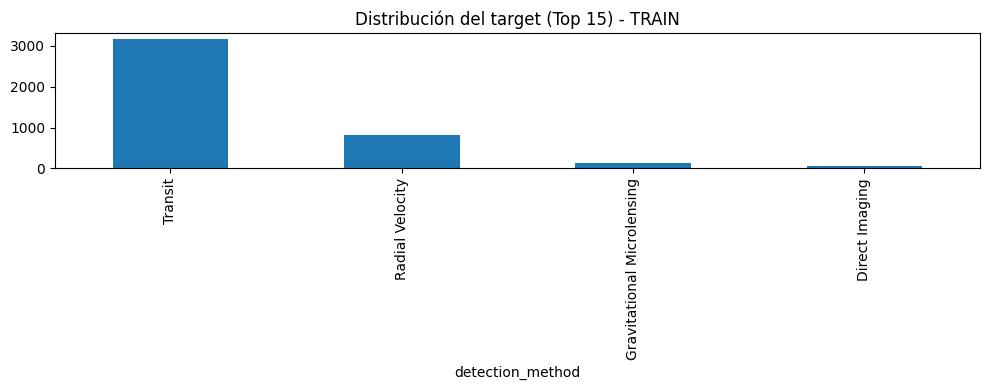

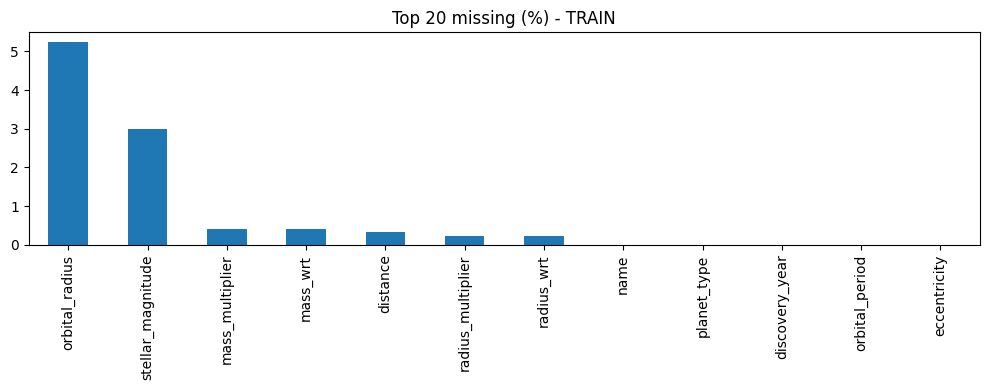

Imputando columnas con <= 6.0% missing:
- distance: mediana = 1393.0
- stellar_magnitude: mediana = 13.556
- mass_multiplier: mediana = 4.27
- mass_wrt: moda = Earth
- radius_multiplier: mediana = 1.12
- radius_wrt: moda = Jupiter
- orbital_radius: mediana = 0.1028

Missing total (celdas) tras imputar: 0

Data report (top 20):
                     dtype  missing_%  unique  cardin_%
name                object        0.0    4150    100.00
stellar_magnitude  float64        0.0    2463     59.35
orbital_radius     float64        0.0    2412     58.12
distance           float64        0.0    2225     53.61
mass_multiplier    float64        0.0    1514     36.48
orbital_period     float64        0.0    1113     26.82
radius_multiplier  float64        0.0     910     21.93
eccentricity       float64        0.0     162      3.90
discovery_year       int64        0.0      28      0.67
planet_type         object        0.0       5      0.12
mass_wrt            object        0.0       2      0.05

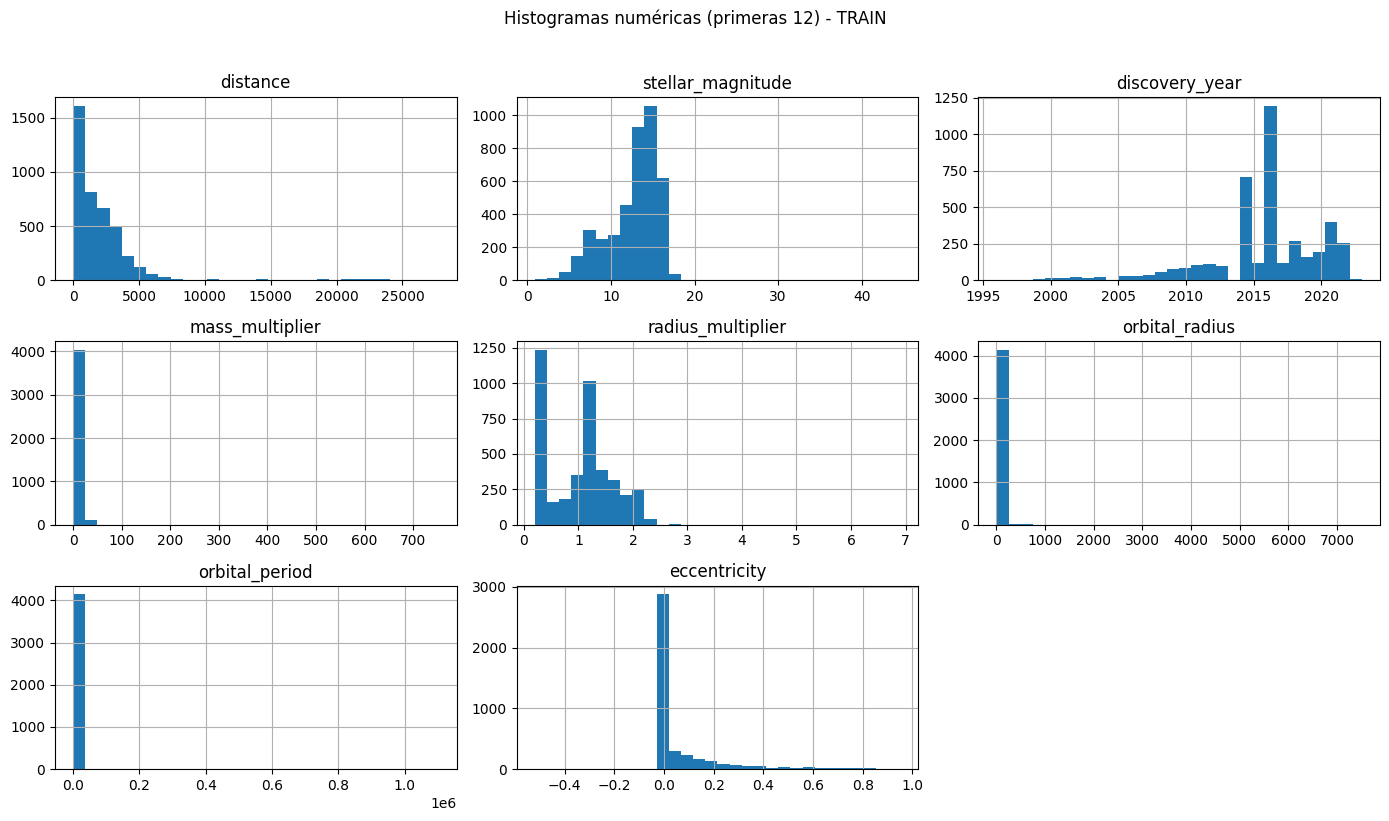

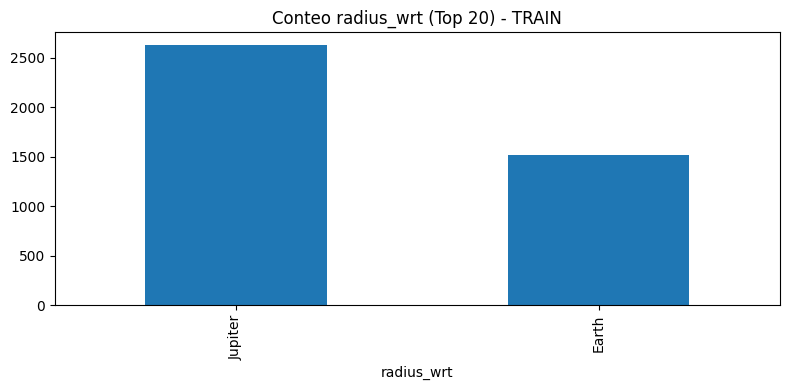

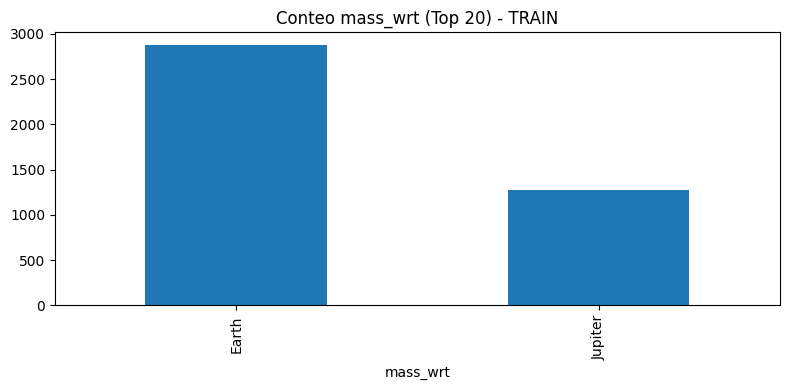

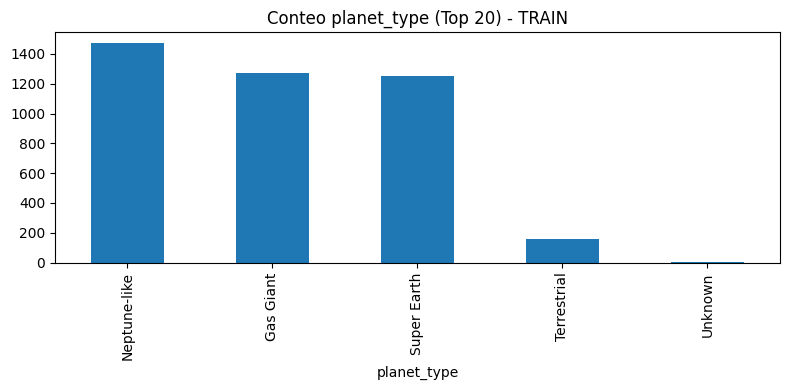

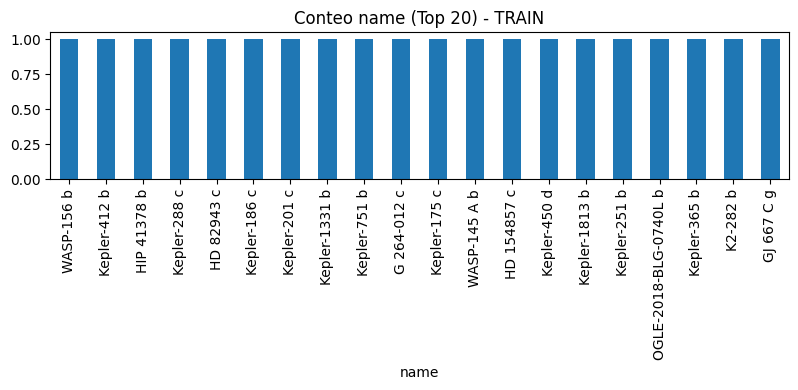

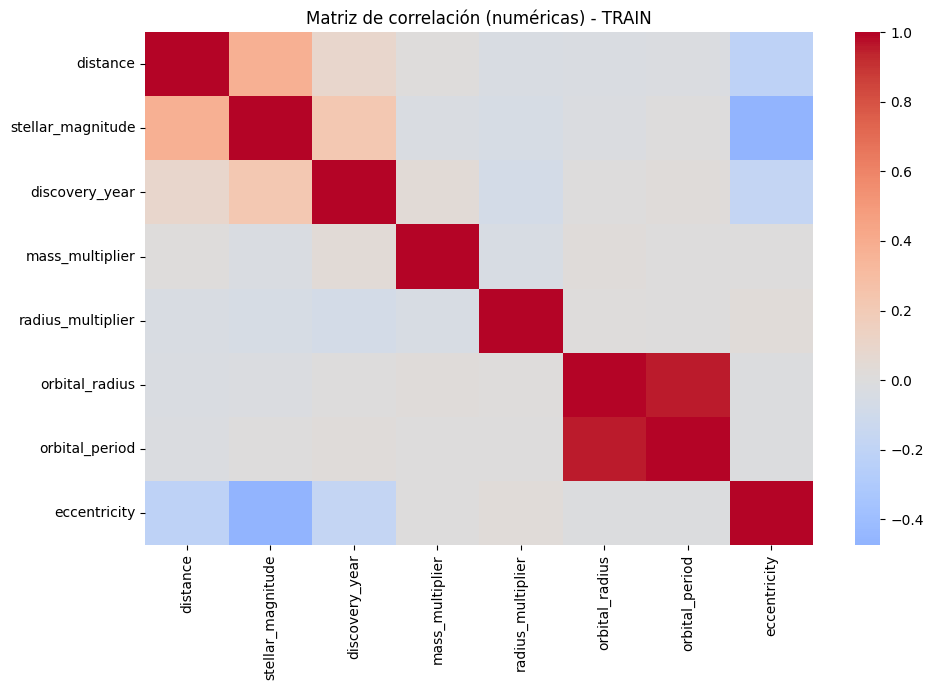

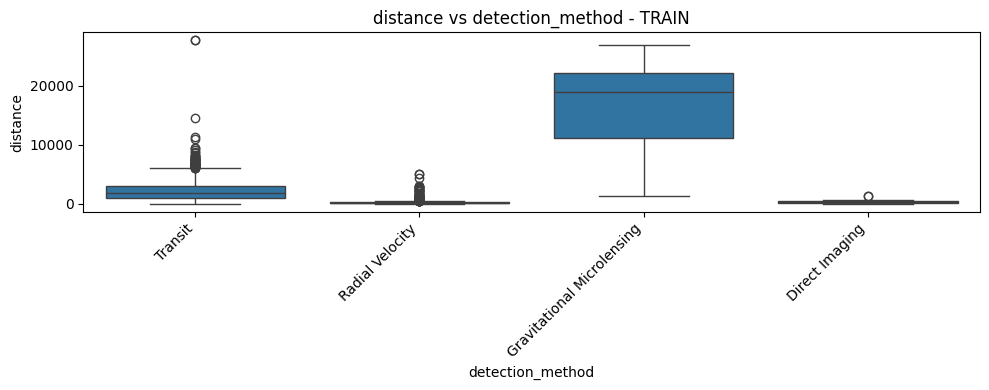

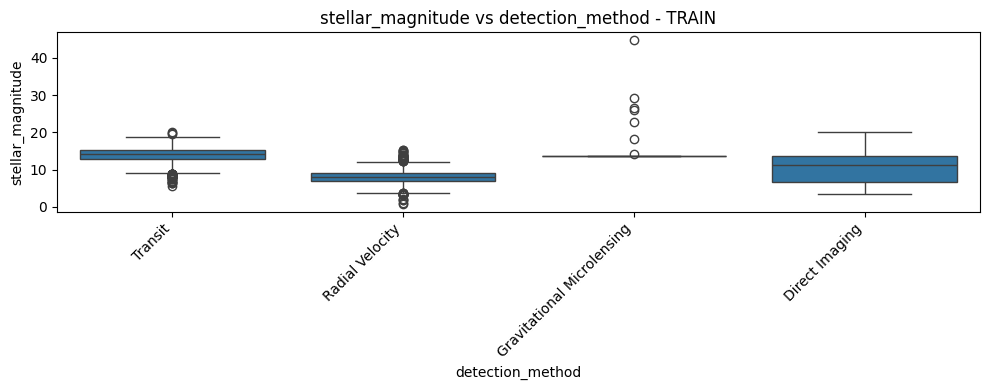

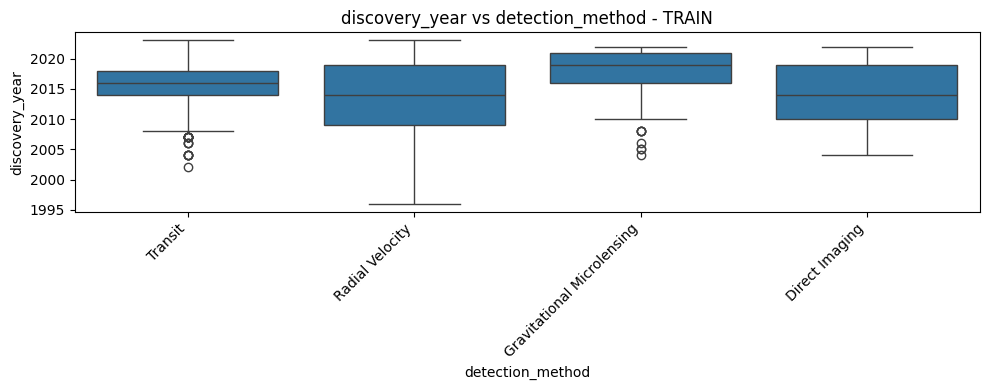

<Figure size 900x400 with 0 Axes>

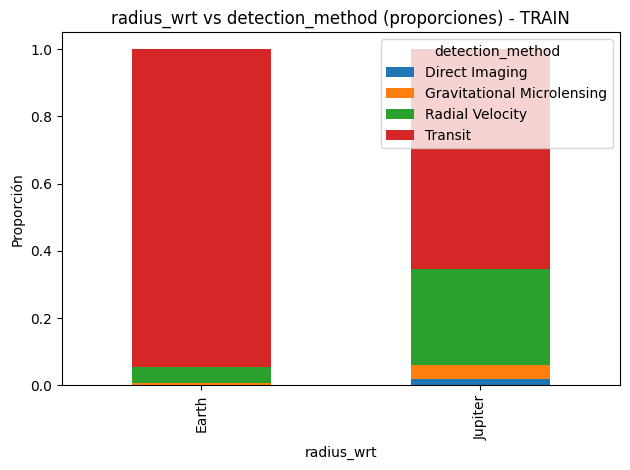

<Figure size 900x400 with 0 Axes>

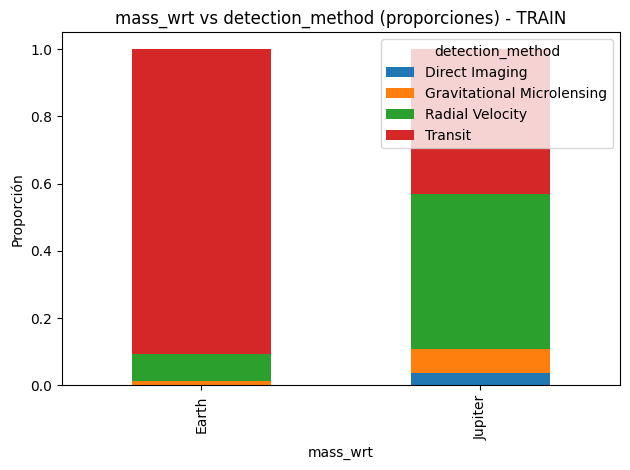

In [7]:
eda_basic(X_train, y_train, target_name=target_col, img_dir="src/img")

### Conclusiones del EDA

- El dataset tiene un tamaño suficiente para entrenar un modelo (miles de filas) y combina variables numéricas (masa, radio, periodo orbital, etc.) y categóricas (por ejemplo unidades o categorías).
- Los valores missing eran bajos en general (la columna con más missing rondaba ~5%), por lo que **no era necesario eliminar columnas** por falta de datos. Aun así, se revisó el porcentaje de missing y se decidió imputar en el pipeline para no perder información.
- La variable objetivo `detection_method` está **muy desbalanceada**: hay un método claramente mayoritario (Transit) y varios minoritarios (p. ej. Direct Imaging). Esto explica por qué la accuracy puede ser engañosa y por qué usamos **F1-macro** como métrica principal.
- La columna `name` se comporta como un identificador (muchísimos valores únicos), así que se eliminó en la reducción preliminar porque no ayuda a generalizar y podría hacer que el modelo memorice.
- En la matriz de correlación se observan relaciones entre algunas variables numéricas, lo que justifica revisar redundancia y mantener un preprocesado robusto (imputación + escalado para numéricas y one-hot para categóricas).
- En los boxplots/histogramas aparecen valores extremos en algunas variables numéricas, por lo que se revisaron outliers y se aplicó un tratamiento sencillo (clipping) para evitar que dominen el entrenamiento.

### Reducción preliminar de variables

Quitamos cosas claramente poco útiles:
- constantes
- columnas tipo ID (casi únicas)
- demasiados missings
- categóricas con demasiados niveles

In [8]:
X_train_red, X_test_red, dropped_cols = preliminary_feature_reduction(X_train, X_test)
print("Columnas eliminadas:", dropped_cols)


=== Reducción preliminar ===
Constantes: 0
Missing > 40.0%: 0
ID-like (cardin > 60.0%): 1
Cat con > 200 niveles: 1
TOTAL a eliminar: 1
Drop cols: ['name']
Columnas eliminadas: ['name']


### Outliers y relevancia de variables del TRAIN

Aquí detectamos valores extremos en variables numéricas y aplicamos un tratamiento sencillo (clipping por IQR).
También sacamos un ranking simple de features más relevantes para el target usando Mutual Information.

=== OUTLIERS (IQR) - TRAIN ===
distance: outliers = 157 (3.80%)
stellar_magnitude: outliers = 56 (1.39%)
discovery_year: outliers = 204 (4.92%)
mass_multiplier: outliers = 265 (6.41%)
radius_multiplier: outliers = 1 (0.02%)
orbital_radius: outliers = 690 (17.54%)
orbital_period: outliers = 798 (19.23%)
eccentricity: outliers = 597 (14.39%)


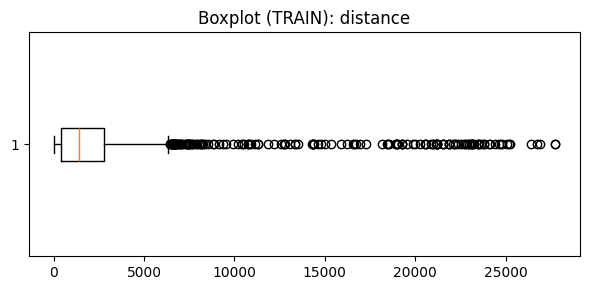

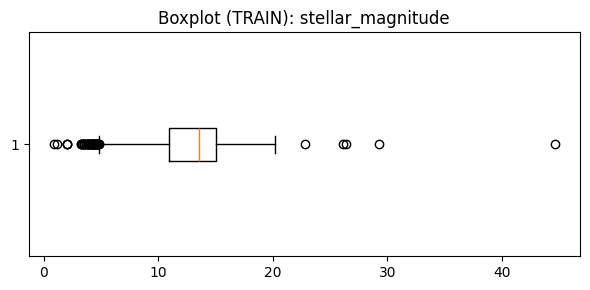

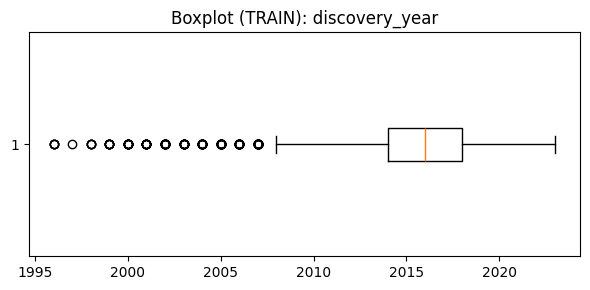

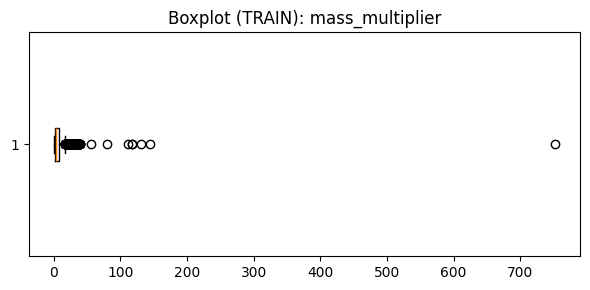

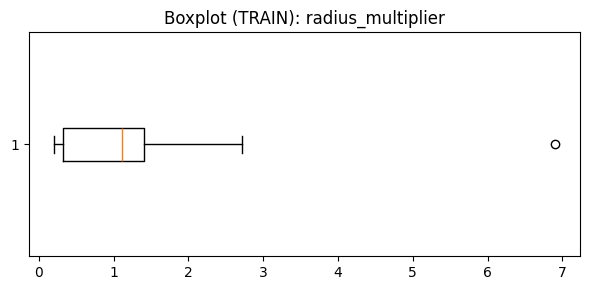

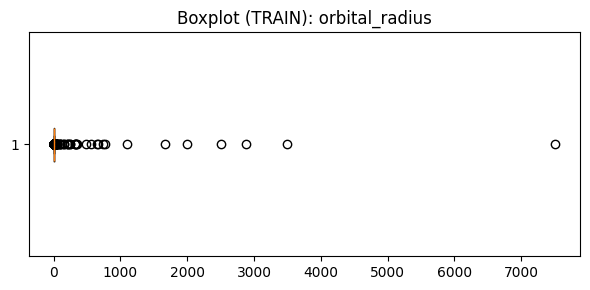

In [9]:
outlier_report(X_train_red)

In [10]:
X_train_red, X_test_red = clip_outliers_iqr(X_train_red, X_test_red)


=== CLIPPING OUTLIERS (IQR) ===
distance: recortados train=157 | test=45
stellar_magnitude: recortados train=56 | test=15
discovery_year: recortados train=204 | test=46
mass_multiplier: recortados train=265 | test=71
radius_multiplier: recortados train=1 | test=0
orbital_radius: recortados train=690 | test=163
orbital_period: recortados train=798 | test=191
eccentricity: recortados train=597 | test=144



=== FEATURES MÁS RELEVANTES (Mutual Information) ===
stellar_magnitude    0.4844
distance             0.3803
orbital_period       0.2507
orbital_radius       0.2483
eccentricity         0.2223
radius_multiplier    0.1860
discovery_year       0.1623
planet_type          0.1424
mass_wrt             0.1272
mass_multiplier      0.0823


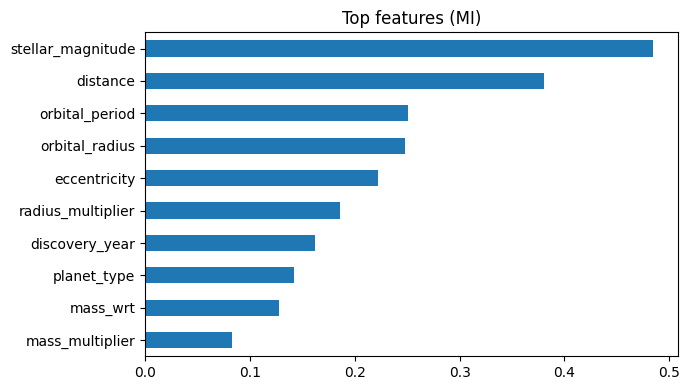

In [11]:
mi_rank = feature_relevance_mi(X_train_red, y_train, top=10)

### Modelos baseline + validación cruzada (CV)

Probamos varios modelos con CV y escogemos el mejor por **F1-macro**:
- Dummy (baseline)
- Logistic Regression
- Random Forest
- Gradient Boosting

In [12]:
pre = build_preprocessor(X_train_red)
pipes, leaderboard, best_name = compare_models_cv(X_train_red, y_train, pre, seed=42)
leaderboard

Preprocessor listo. Num: 8 | Cat: 3

=== Leaderboard (CV) ===
 model  f1_macro  accuracy
    RF  0.927572  0.974217
   GBC  0.925489  0.975663
LogReg  0.856081  0.948193
 Dummy  0.215987  0.760482
Mejor por f1_macro: RF


,model,f1_macro,accuracy
2,RF,0.927572,0.974217
3,GBC,0.925489,0.975663
1,LogReg,0.856081,0.948193
0,Dummy,0.215987,0.760482


### Búsqueda de hiperparámetros (RandomizedSearchCV):

Ajustamos hiperparámetros del mejor modelo usando CV y optimizando F1-macro

In [13]:
if best_name == "Dummy":
    best_name = "LogReg"

best_model, best_params, best_cv = tune_model(best_name, pipes[best_name], X_train_red, y_train, seed=42)
print(best_params, best_cv)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejor f1_macro CV: 0.9233552348897144
Mejores params: {'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__max_depth': None}
{'model__n_estimators': 600, 'model__min_samples_split': 2, 'model__max_depth': None} 0.9233552348897144


### Evaluación final en TEST

Evaluamos el modelo final en el conjunto de test (classification report + matriz de confusión).


=== TEST report ===
                            precision    recall  f1-score   support

            Direct Imaging       1.00      0.92      0.96        12
Gravitational Microlensing       0.97      1.00      0.98        31
           Radial Velocity       0.95      0.97      0.96       206
                   Transit       0.99      0.99      0.99       789

                  accuracy                           0.98      1038
                 macro avg       0.98      0.97      0.97      1038
              weighted avg       0.98      0.98      0.98      1038



<Figure size 800x600 with 0 Axes>

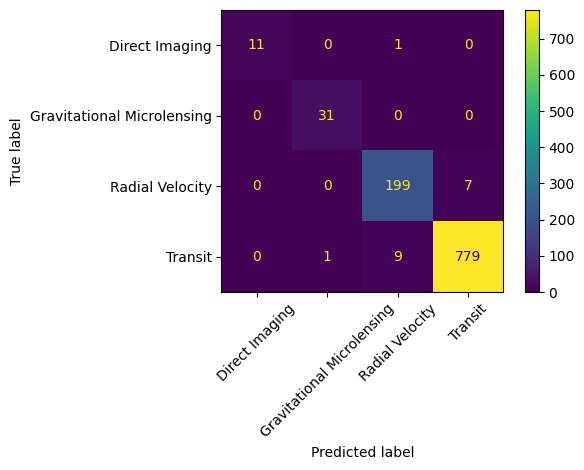

In [14]:
preds = evaluate_model(best_model, X_test_red, y_test, img_dir="src/img")

### Conclusiones de la evaluación del modelo

- La matriz de confusión confirma que el modelo acierta muy bien la clase mayoritaria (Transit) y también funciona bien con Radial Velocity.
- Los errores más comunes se concentran en las clases con menos ejemplos (por ejemplo Direct Imaging), donde es más fácil confundirlas con otras porque hay pocos casos para aprender patrones estables.
- Esto es coherente con el desbalanceo: aunque el rendimiento global sea muy alto, las clases minoritarias tienen más riesgo de bajar en recall (se “escapan” ejemplos que deberían ser de esa clase).
- Para mejorar específicamente esas clases, se podría:
  - usar `class_weight="balanced"` en algunos modelos,
  - hacer re-muestreo (oversampling),
  - o agrupar clases raras si el objetivo del proyecto lo permite.

- El baseline (Dummy) consigue una accuracy relativamente alta porque predice casi siempre la clase mayoritaria, pero su **F1-macro es bajo**, así que no es un modelo útil para todas las clases.
- Al comparar modelos con validación cruzada, los modelos de árboles (Random Forest / Gradient Boosting) funcionan mucho mejor que una regresión logística, lo que sugiere que hay relaciones no lineales importantes entre variables.
- Con tuning de hiperparámetros (RandomizedSearchCV) se consigue un modelo final con resultados muy altos en test (accuracy cercana a 0.98 y F1-macro alta), lo que indica que el método de detección es muy predecible a partir de las variables disponibles.
- La métrica principal usada es **F1-macro** porque hay desbalanceo: así evitamos “premiar” a un modelo que solo acierta Transit y falla el resto.
- Aun con buen rendimiento global, el modelo puede estar aprovechando **sesgos del catálogo** (qué planetas suelen encontrarse con cada técnica). Esto no es malo para el objetivo del proyecto, pero conviene mencionarlo como limitación.

### Guardado del modelo y resultados

In [15]:
info = {
    "target": target_col,
    "best_model": best_name,
    "best_params": best_params,
    "best_cv_f1_macro": best_cv,
    "train_shape": [int(X_train_red.shape[0]), int(X_train_red.shape[1])],
    "test_shape": [int(X_test_red.shape[0]), int(X_test_red.shape[1])],
}

save_model_and_card(
    best_model,
    model_path="src/models/best_model_detection_method.joblib",
    card_path="src/models/model_card_detection_method.json",
    info=info
)

✅ Modelo guardado en: src\models\best_model_detection_method.joblib
🧾 Model card guardada en: src\models\model_card_detection_method.json


## Conclusiones finales del proyecto

- Se ha planteado un problema claro: **predecir el método de detección (`detection_method`)** a partir de características del exoplaneta y su sistema.
- Tiene sentido usar Machine Learning porque la relación entre variables físicas/observacionales y el método de detección no es trivial, y además es un problema de **clasificación multiclase** con desbalanceo.
- Se siguió un flujo completo: carga y limpieza, split train/test, EDA dirigido, reducción preliminar de features, pipeline de preprocesado, comparación de modelos con validación cruzada, búsqueda de hiperparámetros y evaluación final en test.
- El modelo final obtiene muy buen rendimiento y muestra que el dataset contiene suficiente información para diferenciar métodos de detección.
- Como trabajo futuro, se podría:
  - repetir el mismo pipeline para predecir otro target (por ejemplo `planet_type` o estimar masa/radio),
  - mejorar el tratamiento de clases minoritarias,
  - y analizar interpretabilidad (importancias / SHAP) para entender qué variables influyen más en cada método.